<a href="https://colab.research.google.com/github/ananthojusankethkumar/Credit_card_fraud_detection_system/blob/main/EMG_Signal_Classification_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
!ls /content/drive/MyDrive/dat

'subject 1'  'subject 3'  'subject 5'  'subject 7'
'subject 2'  'subject 4'  'subject 6'  'subject 8'


In [40]:
import os

data_root = '/content/drive/MyDrive/dat'
emg_records = {}

for folder in sorted(os.listdir(data_root)):
    folder_path = os.path.join(data_root, folder)
    if os.path.isdir(folder_path):
        print(f"Loading {folder}...")
        for file in os.listdir(folder_path):
            if file.endswith(('.csv', '.txt')):
                path = os.path.join(folder_path, file)
                name = f"{folder}_{file.split('.')[0]}"
                try:
                    df = pd.read_csv(path, sep=None, engine='python')
                    if not df.empty:
                        emg_records[name] = df
                except Exception as error:
                    print(f"Error loading {file}: {error}")

print(f"\nTotal loaded: {len(emg_records)} files.")

Loading subject 1...
Loading subject 2...
Loading subject 3...
Loading subject 4...
Loading subject 5...
Loading subject 6...
Loading subject 7...
Loading subject 8...

Total loaded: 40 files.


In [41]:
from scipy.signal import butter, lfilter

def apply_bandpass(data, low, high, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return lfilter(b, a, data)

filtered_records = {}
srate, low, high = 1000, 20, 450

for name, df in emg_records.items():
    proc = df.copy()
    nums = proc.select_dtypes(include=np.number).columns
    for c in nums:
        proc[c] = apply_bandpass(proc[c], low, high, srate)
    filtered_records[name] = proc

print("Filtering complete.")

Filtering complete.


In [42]:
from sklearn.preprocessing import MinMaxScaler

normalized_records = {}
scaler = MinMaxScaler()

for name, df in filtered_records.items():
    norm = df.copy()
    nums = norm.select_dtypes(include=np.number).columns
    for c in nums:
        norm[c] = scaler.fit_transform(norm[[c]])
    normalized_records[name] = norm

print("Normalization complete.")

Normalization complete.


In [43]:
gestures = {'0':'Open', '1':'Close', '2':'Grip', '3':'Relax', '4':'Extended'}

def identify_gesture(key):
    return gestures.get(key.split('_')[-1], 'Unknown')

In [23]:
all_features = []

# Check if normalized data exists
if not emg_data_normalized:
    print("Error: 'emg_data_normalized' is empty. Please run the preprocessing cells first.")
else:
    for key, df_normalized in emg_data_normalized.items():
        gesture_label = extract_gesture_label_updated(key)

        if gesture_label == 'Unknown':
            continue

        # Identify EMG columns (numerical columns)
        emg_columns = df_normalized.select_dtypes(include=np.number).columns

        # Slide the window across the data
        for i in range(0, len(df_normalized) - window_size + 1, step_size):
            window_data = df_normalized.iloc[i : i + window_size]
            window_features = {'label': gesture_label}

            for col in emg_columns:
                segment = window_data[col].values
                # Use the previously defined calculate_features function
                feat = calculate_features(segment)
                for name, val in feat.items():
                    window_features[f'{col}_{name}'] = val

            all_features.append(window_features)

    features_df = pd.DataFrame(all_features)
    print(f"Extracted {len(features_df)} feature vectors.")
    print("\nGesture Distribution:")
    display(features_df['label'].value_counts())
    display(features_df.head())

Extracted 8168 feature vectors.

Gesture Distribution:


,count
label,
Relax,1658
Close,1636
Extended,1634
Open,1626
Grip,1614


,label,0.01206021595176814_MAV,0.01206021595176814_RMS,0.01206021595176814_ZC,0.01206021595176814_WL,0.007171891609228833_MAV,0.007171891609228833_RMS,0.007171891609228833_ZC,0.007171891609228833_WL,-0.004912304839152804_MAV,...,0.04734363312902128_ZC,0.04734363312902128_WL,-0.1125384170465302_MAV,-0.1125384170465302_RMS,-0.1125384170465302_ZC,-0.1125384170465302_WL,-0.02313602559563311_MAV,-0.02313602559563311_RMS,-0.02313602559563311_ZC,-0.02313602559563311_WL
0,Open,0.528627,0.535668,0.0,8.362608,0.442929,0.465387,0.0,10.802631,0.530168,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Open,0.527172,0.533874,0.0,8.787956,0.437438,0.455051,0.0,9.160301,0.531431,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Open,0.527801,0.535115,0.0,8.533567,0.442355,0.455810,0.0,8.816116,0.531181,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Open,0.530220,0.536025,0.0,7.349255,0.446620,0.461312,0.0,9.483964,0.530956,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Open,0.530812,0.535697,0.0,7.109580,0.442697,0.462016,0.0,10.407597,0.529415,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
def extract_stats(sig):
    if len(sig) == 0: return {'MAV':0, 'RMS':0, 'ZC':0, 'WL':0}
    zc = np.sum(((sig[:-1] * sig[1:]) < 0) & (np.abs(sig[:-1]) > 0.01))
    return {
        'MAV': np.mean(np.abs(sig)),
        'RMS': np.sqrt(np.mean(sig**2)),
        'ZC': zc,
        'WL': np.sum(np.abs(np.diff(sig)))
    }

win, step, data_points = 200, 100, []

for name, df in normalized_records.items():
    label = identify_gesture(name)
    if label == 'Unknown': continue
    cols = df.select_dtypes(include=np.number).columns

    for i in range(0, len(df) - win + 1, step):
        chunk = df.iloc[i : i + win]
        row = {'label': label}
        for c in cols:
            stats = extract_stats(chunk[c].values)
            for k, v in stats.items():
                row[f"{c}_{k}"] = v
        data_points.append(row)

features_df = pd.DataFrame(data_points)
print(f"Extracted {len(features_df)} samples.")

Extracted 8168 samples.


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

if not features_df.empty:
    X = features_df.drop('label', axis=1).fillna(0)
    y = features_df['label']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)

    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(classification_report(y_test, preds))

Accuracy: 1.0000
              precision    recall  f1-score   support

       Close       1.00      1.00      1.00       491
    Extended       1.00      1.00      1.00       490
        Grip       1.00      1.00      1.00       484
        Open       1.00      1.00      1.00       488
       Relax       1.00      1.00      1.00       498

    accuracy                           1.00      2451
   macro avg       1.00      1.00      1.00      2451
weighted avg       1.00      1.00      1.00      2451



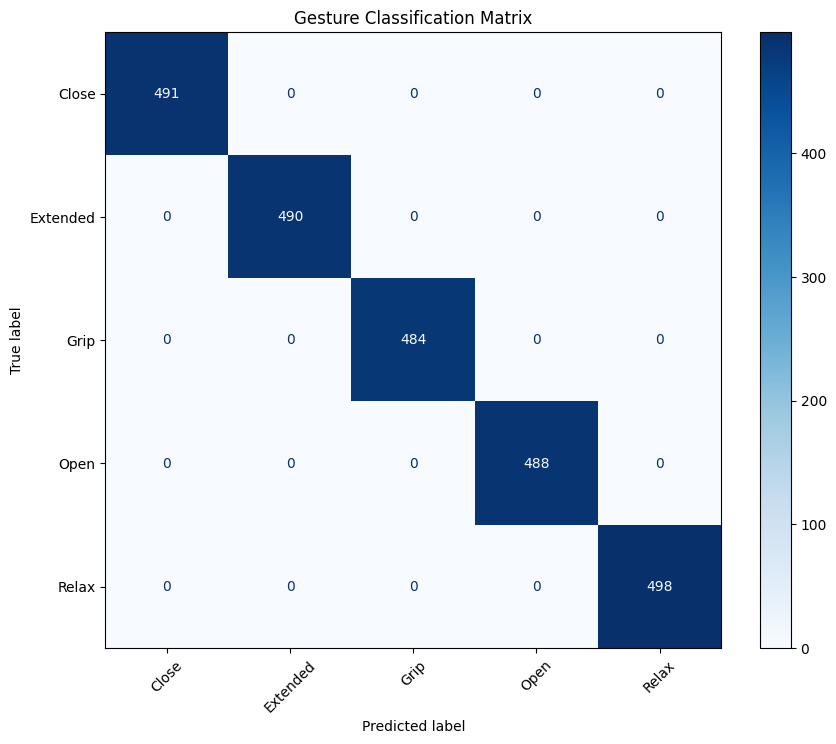

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

matrix = confusion_matrix(y_test, preds, labels=clf.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(matrix, display_labels=clf.classes_).plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Gesture Classification Matrix')
plt.show()

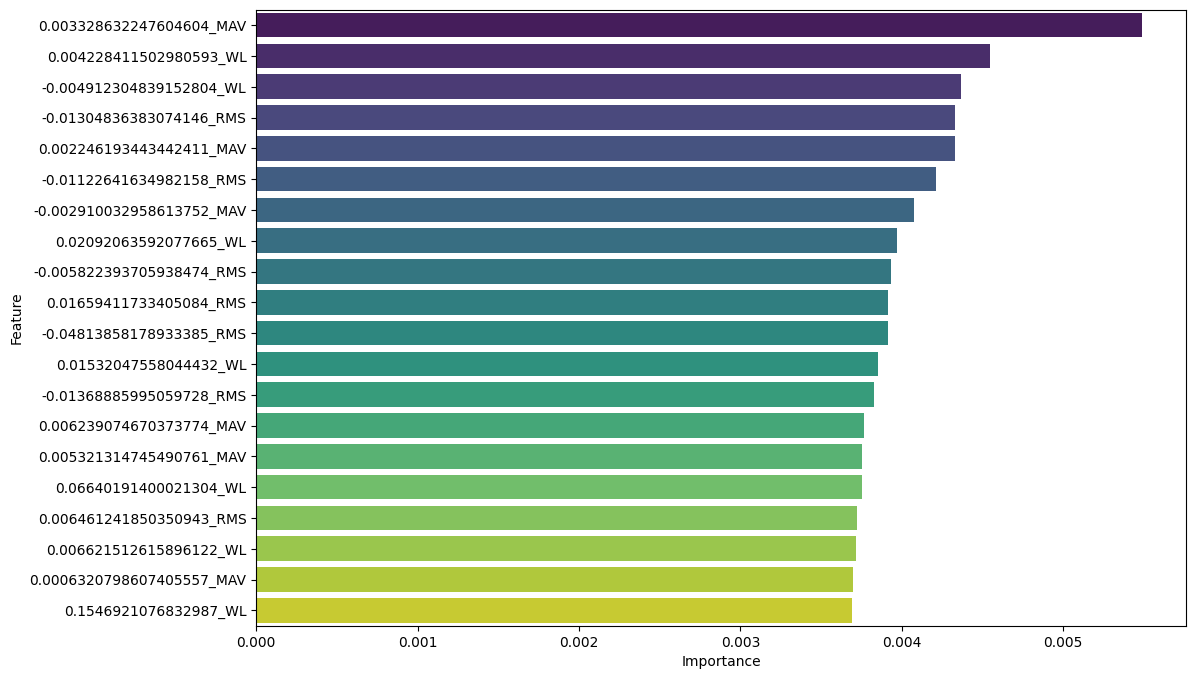

MAV: 0.3388
RMS: 0.3317
ZC: 0.0000
WL: 0.3295


In [47]:
rank = pd.DataFrame({'Feature': X.columns, 'Importance': clf.feature_importances_}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=rank.head(20), palette='viridis', hue='Feature', legend=False)
plt.show()

for m in ['MAV', 'RMS', 'ZC', 'WL']:
    val = rank[rank['Feature'].str.contains(m)]['Importance'].sum()
    print(f"{m}: {val:.4f}")

In [49]:
def predict_demo(sample_df, model, train_columns, win_size=200):
    chunk = sample_df.iloc[:win_size]
    nums = chunk.select_dtypes(include=np.number).columns
    feats = {}

    for c in nums:
        stats = extract_stats(chunk[c].values)
        for k, v in stats.items():
            feats[f'{c}_{k}'] = v

    test_df = pd.DataFrame([feats])
    test_df = test_df.reindex(columns=train_columns, fill_value=0)

    return model.predict(test_df)[0]

if 'normalized_records' in locals() and normalized_records:
    train_cols = X.columns
    test_name = list(normalized_records.keys())[0]
    res = predict_demo(normalized_records[test_name], clf, train_cols)
    print(f"File: {test_name} | Predicted Gesture: {res}")

File: subject 1_0 | Predicted Gesture: Open


In [50]:
import random

if 'normalized_records' in locals() and normalized_records:
    test_name = random.choice(list(normalized_records.keys()))
    true_label = identify_gesture(test_name)

    prediction = predict_demo(normalized_records[test_name], clf, X.columns)

    print(f"Selected File: {test_name}")
    print(f"True Gesture: {true_label}")
    print(f"Predicted Gesture: {prediction}")

    if true_label == prediction:
        print("\nResult: Correct Prediction!")
    else:
        print("\nResult: Incorrect Prediction.")

Selected File: subject 8_4
True Gesture: Extended
Predicted Gesture: Extended

Result: Correct Prediction!
